# 04 - Evaluating the RAG pipeline

## Evaluate each part separately

A fluent answer can hide bad retrieval, and good retrieval doesn't guarantee a grounded answer. So this notebook scores retrieval, context, generation and system behavior separately against a labeled question set.

In [1]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
core_notebook_path = ROOT / "notebooks/_rag_demo_core.ipynb"
get_ipython().run_line_magic("run", f'"{core_notebook_path}"')
DATA = ROOT / "data"
ARTIFACTS = ROOT / "artifacts"
print(f"Project root: {ROOT}")
openai_settings = get_openai_settings(require_api_key=False)
print(f"OpenAI configured: {openai_settings.configured}; "
      f"embedding={openai_settings.embedding_model}; chat={openai_settings.chat_model}")


Project root: /Users/snomula/Downloads/sripal/Context Engineern-RAG
OpenAI configured: False; embedding=text-embedding-3-small; chat=gpt-5-mini


In [2]:
import json, time
import pandas as pd
import matplotlib.pyplot as plt
generate_pdf(DATA / "raw/northstar_safety_bulletin.pdf")

cases = [json.loads(line) for line in (DATA / "eval/questions.jsonl").read_text().splitlines()]
documents = load_corpus(DATA / "raw")
embedder = get_embedder()


### Metrics

- **Hit Rate@k**: at least one relevant document shows up in the top k.
- **Recall@k**: share of labeled relevant documents that were retrieved.
- **Precision@k**: share of top-k results that come from a relevant document.
- **MRR**: reciprocal rank of the first relevant result.
- **nDCG@k**: rewards relevant results that rank higher.
- **Evidence coverage**: share of labeled evidence phrases found in the context.
- **Context precision**: share of retrieved chunks that contain any labeled evidence.
- **Token F1**: token overlap between answer and reference.
- **Answer relevance**: embedding similarity between question and answer.
- **Groundedness**: share of answer sentences supported by the context.
- **Citation validity**: share of citations that point to retrieved chunks.

The last four are rough proxies. For a real benchmark you'd add human labels and check any LLM judge against them.

In [3]:
configurations = {}
for strategy, kwargs in [("fixed", {"size": 80, "overlap": 15}),
                         ("document_aware", {"max_words": 110, "overlap": 15})]:
    chunks = chunk_corpus(documents, strategy, **kwargs)
    vector_store = ChromaVectorStore(
        ARTIFACTS / "chroma", collection_name(f"eval-{strategy}-v2", embedder), embedder)
    vector_store.upsert(chunks)
    configurations[strategy] = (chunks, vector_store, BM25Retriever(chunks))


In [4]:
use_openai_generation = env_flag("RAG_EVAL_USE_OPENAI", False)
openai_generator = OpenAIRAGGenerator() if use_openai_generation else None
print("Generation evaluator:", "OpenAI Responses API" if use_openai_generation else "extractive baseline")
rows = []
details = {}
for config_name, (chunks, vector_store, lexical) in configurations.items():
    for case in cases:
        started = time.perf_counter()
        # no metadata filters here so the labels don't help retrieval
        results = hybrid_query(case["question"], vector_store, lexical, k=5)
        answer = (openai_generator.generate(case["question"], results)
                  if openai_generator else generate_extractive_answer(case["question"], results))
        row = evaluate_case(case, results, answer, k=5)
        row.update(config=config_name, latency_ms=(time.perf_counter()-started)*1000,
                   context_words=sum(len(r.chunk.text.split()) for r in results))
        rows.append(row)
        details[(config_name, case["id"])] = (results, answer)

scores = pd.DataFrame(rows)
summary = scores.groupby("config").mean(numeric_only=True).round(3)
summary


Generation evaluator: extractive baseline


,hit_rate,recall_at_k,precision_at_k,mrr,ndcg_at_k,evidence_coverage,context_precision,token_f1,answer_relevance,groundedness,citation_validity,abstained,latency_ms,context_words
config,,,,,,,,,,,,,,
document_aware,1.0,0.95,0.48,0.933,0.572,0.867,0.28,0.260,0.279,0.9,1.0,0.0,1.713,199.1
fixed,1.0,0.95,0.44,0.950,0.549,0.867,0.32,0.192,0.296,0.9,1.0,0.0,1.813,368.9


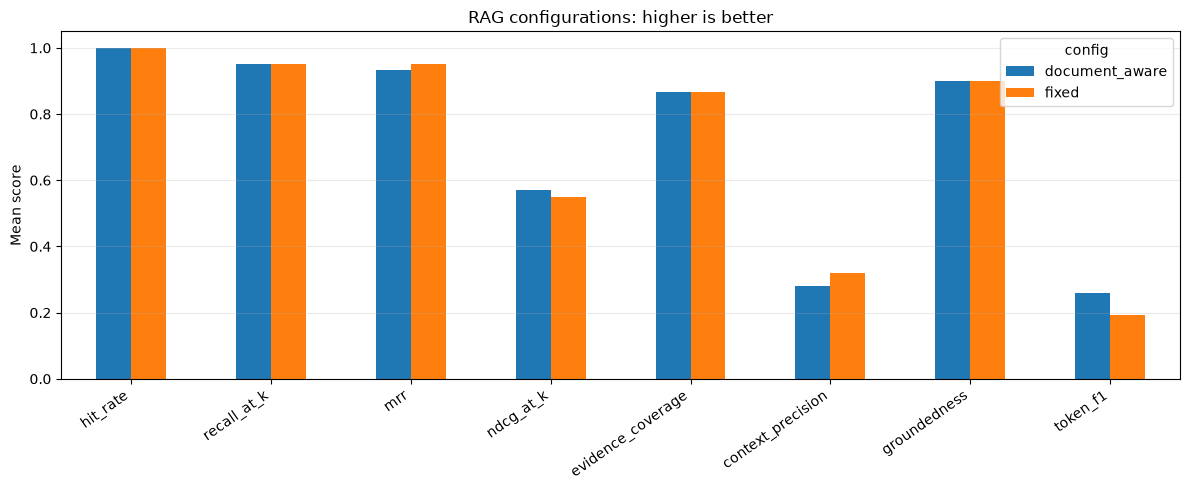

In [5]:
display_columns = ["hit_rate", "recall_at_k", "mrr", "ndcg_at_k",
                   "evidence_coverage", "context_precision", "groundedness", "token_f1"]
ax = summary[display_columns].T.plot(kind="bar", figsize=(12, 5), ylim=(0, 1.05))
ax.set_title("RAG configurations: higher is better")
ax.set_ylabel("Mean score")
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()


### Look at failures, not just the average

Break results down by category and read the context for the worst cases. That usually tells you whether the fix belongs in parsing, chunking, retrieval, reranking, the prompt or the model.

In [6]:
category_view = scores.groupby(["config", "category"])[
    ["hit_rate", "evidence_coverage", "context_precision", "groundedness"]
].mean().round(2)
category_view


hit_rate  evidence_coverage  \
config         category                                         
document_aware json_record             1.0               1.00   
               multi_document          1.0               1.00   
               multi_fact              1.0               1.00   
               negation                1.0               1.00   
               pdf                     1.0               1.00   
               policy                  1.0               0.33   
               table_calculation       1.0               1.00   
               table_lookup            1.0               1.00   
fixed          json_record             1.0               1.00   
               multi_document          1.0               1.00   
               multi_fact              1.0               1.00   
               negation                1.0               1.00   
               pdf                     1.0               1.00   
               policy                  1.0               0.33   
               table_calculation       1.0               1.00   
               table_lookup            1.0               1.00   

                                  context_precision  groundedness  
config         category                                            
document_aware json_record                      0.2           1.0  
               multi_document                   0.2           1.0  
               multi_fact                       0.2           1.0  
               negation                         0.2           1.0  
               pdf                              0.2           1.0  
               policy                           0.1           1.0  
               table_calculation                1.0           0.0  
               table_lookup                     0.3           1.0  
fixed          json_record                      0.2           1.0  
               multi_document                   0.4           1.0  
               multi_fact                       0.4           1.0  
               negation                         0.2           1.0  
               pdf                              0.2           1.0  
               policy                           0.1           1.0  
               table_calculation                0.6           0.0  
               table_lookup                     0.5           1.0

In [7]:
failures = scores.sort_values(["evidence_coverage", "mrr"]).head(5)
for _, failure in failures.iterrows():
    results, answer = details[(failure["config"], failure["id"])]
    case = next(c for c in cases if c["id"] == failure["id"])
    print("\n", "="*80, f"\n{failure['config']} | {case['question']}")
    print("Expected evidence:", case["evidence_phrases"])
    print("Answer:", answer.text)
    print("Retrieved:", [(r.chunk.doc_id, r.chunk.chunk_id) for r in results])



fixed | How many days per week may a Seattle employee work remotely?
Expected evidence: ['up to three days per week']
Answer: # Northstar Mobility Employee Handbook Document ID: `handbook-2026` Version: 3.2 Effective date: 2026-01-15 Owner: People Operations ## Hybrid work Employees assigned to the Seattle office may work remotely up to **three days per week**. [northstar_employee_handbook.md#handbook-2026:fixed:000] ### International remote work International remote work is limited to **20 calendar days per year**. [northstar_employee_handbook.md#handbook-2026:fixed:001] Managers may approve domestic hotel rates up to $275 per night; higher rates require Finance approval. [northstar_employee_handbook.md#handbook-2026:fixed:002]
Retrieved: [('handbook-2026', 'handbook-2026:fixed:000'), ('handbook-2026', 'handbook-2026:fixed:001'), ('handbook-2026', 'handbook-2026:fixed:002'), ('safety-bulletin-2026-04', 'safety-bulletin-2026-04:fixed:000'), ('safety-bulletin-2026-04', 'safety-bulletin

In [8]:
output = ARTIFACTS / "reports/rag_eval.csv"
output.parent.mkdir(parents=True, exist_ok=True)
scores.to_csv(output, index=False)
print("Saved per-question results to", output)


Saved per-question results to /Users/snomula/Downloads/sripal/Context Engineern-RAG/artifacts/reports/rag_eval.csv


## Caveats when reading these numbers

- Labels are document-level for now; chunk-level labels would be stricter.
- With more questions, report confidence intervals.
- Keep separate dev and test sets.
- Include unanswerable questions to check that the system abstains.
- Track cost, p50/p95 latency and context size next to quality.
- The groundedness score here is a heuristic. Don't present it (or an LLM judge) as ground truth.